In [21]:
from dopplerguesser.predict.fetch_tles import fetch_tles
from dopplerguesser.predict.filters import filter_visibility, filter_heo, filter_geostationary, filter_by_doppler, filter_constellations
from dopplerguesser.predict.matcher import score_candidates
from dopplerguesser.predict.observer import Observer
from dopplerguesser.predict.satellite import Satellite
from dopplerguesser.predict.propagator import propagate_earth_rotation, propagate_fg_elliptic
from dopplerguesser.misc.curve_generator import generate_doppler_curve
from matplotlib import pyplot as plt

In [22]:
from time import perf_counter
from datetime import datetime
from datetime import timezone

In [23]:
observer = Observer(lat=55.7558, lon=37.6176, alt=200)  # Moscow

In [24]:
now = datetime.now(tz=timezone.utc)
print(now)
ts = now.timestamp()
print(ts)

2026-01-28 23:08:47.891804+00:00
1769641727.891804


In [25]:
fetched_tles = fetch_tles(ts)

In [26]:
with open('activesatellites.txt', 'w') as f:
    for sat in fetched_tles:
        f.write(f"{sat.satellite.name}\n")

In [ ]:
# Filtering
print('Initial length:', len(fetched_tles))

t1 = perf_counter()
satellites = filter_constellations(fetched_tles, constellations_to_remove=['starlink', 'oneweb'])
t2 = perf_counter()
print('After constellation filter:', len(satellites))
print('Took {:.3f} seconds\n'.format(t2 - t1))

t1 = perf_counter()
satellites = filter_geostationary(satellites)
t2 = perf_counter()
print('After geostationary filter:', len(satellites))
print('Took {:.3f} seconds\n'.format(t2 - t1))

t1 = perf_counter()
satellites = filter_heo(satellites)
t2 = perf_counter()
print('After HEO filter:', len(satellites))
print('Took: {:.3f} seconds\n'.format(t2 - t1))

t1 = perf_counter()
satellites = filter_visibility(satellites, observer, ts, min_elevation=0.0)
t2 = perf_counter()
print('After visibility filter:', len(satellites))
print('Took: {:.3f} seconds\n'.format(t2 - t1))

Initial length: 14301
After geostationary filter: 13500
Took 0.004 seconds

After HEO filter: 13498
Took: 0.003 seconds

After visibility filter: 553
Took: 0.954 seconds



In [28]:
# Earth rotation Propagation
t1 = perf_counter()
observer.compute_track(ts)
t2 = perf_counter()
print('Earth rotation propagation took {:.3f} seconds\n'.format(t2 - t1))

Earth rotation propagation took 0.009 seconds



In [29]:
# Satellite propagation
t1 = perf_counter()
for sat in satellites:
    sat.compute_initial_state(ts)
t2 = perf_counter()
print('Satellite propagation took {:.3f} seconds\n'.format(t2 - t1))

Satellite propagation took 0.125 seconds



JAS-2 (FO-29)
[(np.int64(0), np.float64(2199996018.0040545)), (np.int64(1), np.float64(2199995891.253924)), (np.int64(2), np.float64(2199995728.915334)), (np.int64(3), np.float64(2199995576.7170877)), (np.int64(4), np.float64(2199995425.445187)), (np.int64(5), np.float64(2199995214.9273953)), (np.int64(6), np.float64(2199995259.259721)), (np.int64(7), np.float64(2199994976.0595484)), (np.int64(8), np.float64(2199994951.990833)), (np.int64(9), np.float64(2199994834.033601)), (np.int64(10), np.float64(2199994661.9601145)), (np.int64(11), np.float64(2199994539.433313)), (np.int64(12), np.float64(2199994539.1516705)), (np.int64(13), np.float64(2199994260.364638)), (np.int64(14), np.float64(2199994183.563296)), (np.int64(15), np.float64(2199994172.9948826)), (np.int64(16), np.float64(2199993924.3829093)), (np.int64(17), np.float64(2199993896.916977)), (np.int64(18), np.float64(2199993659.5231957)), (np.int64(19), np.float64(2199993702.926633)), (np.int64(20), np.float64(2199993518.3393493))

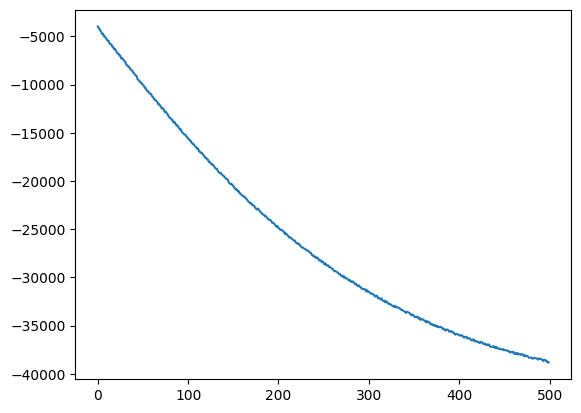

In [30]:
# Mock doppler curve generation
unknownsatellite = satellites[0]
freq = 2.2e9
print(unknownsatellite.satellite.name)
curve = generate_doppler_curve(unknownsatellite, observer, freq, ts)
print(curve)

curveclean = [(x, y - freq) for x, y in curve]

plt.plot(*zip(*curveclean))
plt.show()

In [31]:
# Apply Doppler filter
t1 = perf_counter()
satellites = filter_by_doppler(satellites, observer, ts, freq, curve[0][1])
t2 = perf_counter()
print('After Doppler filter:', len(satellites))
print('Took: {:.3f} seconds\n'.format(t2 - t1))
print('Remaining candidates:')
for sat in satellites:
    print(sat.satellite.name)

After Doppler filter: 19
Took: 0.012 seconds

Remaining candidates:
JAS-2 (FO-29)
LEMUR-2-GREENBERG
JILIN-1 04
ONEWEB-0067
STARLINK-1621
STARLINK-1931
ONEWEB-0420
STARLINK-4330
ONEWEB-0495
STARLINK-5921
STARLINK-30068
STARLINK-31156
STARLINK-31455
STARLINK-32482
STARLINK-11586 [DTC]
STARLINK-32912
STARLINK-33943
STARLINK-34232
STARLINK-35906


In [32]:
# Propagate candidates using FG elliptic model
t1 = perf_counter()
for sat in satellites:
    sat.compute_track(ts)
t2 = perf_counter()
print('FG elliptic propagation took {:.3f} seconds\n'.format(t2 - t1))

FG elliptic propagation took 0.470 seconds



In [33]:
# Score candidates
t1 = perf_counter()
scored_candidates = score_candidates(satellites, curve, freq, observer)
t2 = perf_counter()
print('\nScoring took {:.3f} seconds\n'.format(t2 - t1))
for sat, rmse in scored_candidates:
    print(f'{sat.satellite.name}: {rmse:.6f}')


Scoring took 0.176 seconds

JAS-2 (FO-29): 61.063847
STARLINK-30068: 516.404587
ONEWEB-0420: 957.455233
STARLINK-4330: 2795.397289
STARLINK-32482: 3143.910386
LEMUR-2-GREENBERG: 3226.613405
STARLINK-33943: 6303.138203
STARLINK-31455: 6428.533536
STARLINK-35906: 6913.480640
JILIN-1 04: 7251.097972
STARLINK-31156: 7775.729582
STARLINK-34232: 7963.474143
ONEWEB-0067: 9470.503892
ONEWEB-0495: 9493.663692
STARLINK-1931: 9519.043116
STARLINK-11586 [DTC]: 10122.313630
STARLINK-32912: 10897.486586
STARLINK-5921: 13238.914404
STARLINK-1621: 19689.364482
